# Importing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

# Data Exploration

In [ ]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [ ]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True, errors='ignore')
df.rename(columns={'v1': 'Label', 'v2': 'Message'}, inplace=True)
df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print('dataset shape:',df.shape)

dataset shape: (5572, 2)


In [ ]:
df['Label'].value_counts()

,count
Label,
ham,4825
spam,747


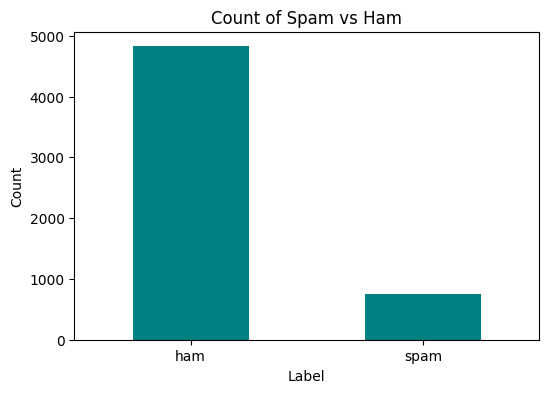

In [ ]:
plt.figure(figsize=(6,4))
df['Label'].value_counts().plot(kind='bar', color='teal', rot=0)
plt.title('Count of Spam vs Ham')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Preprocessing

In [ ]:
nltk.download('stopwords')
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text).lower())
    words = text.split()
    clean_words = [ps.stem(w) for w in words if w not in stop_words]
    return ' '.join(clean_words)

In [ ]:
df['Cleaned_Message'] = df['Message'].apply(clean_text)
df.head()

,Label,Message,Cleaned_Message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [ ]:
X = df['Cleaned_Message']
y = df['Label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    max_df=0.7,
    use_idf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('X_train_tfidf shape:', X_train_tfidf.shape)
print('X_test_tfidf shape:', X_test_tfidf.shape)

X_train_tfidf shape: (4457, 5000)
X_test_tfidf shape: (1115, 5000)


In [ ]:
from imblearn.over_sampling import SMOTE
X_train_resampled, y_train_resampled = SMOTE().fit_resample(X_train_tfidf, y_train)

print('X_train_resampled shape:', X_train_resampled.shape)
print('y_train_resampled shape:', y_train_resampled.shape)

X_train_resampled shape: (7718, 5000)
y_train_resampled shape: (7718,)


# Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix

## Logistic Regression

In [ ]:
log_reg = LogisticRegression(C=1.0, class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_resampled, y_train_resampled)

y_pred_lr = log_reg.predict(X_test_tfidf)
y_probs_lr = log_reg.predict_proba(X_test_tfidf)[:, 1]

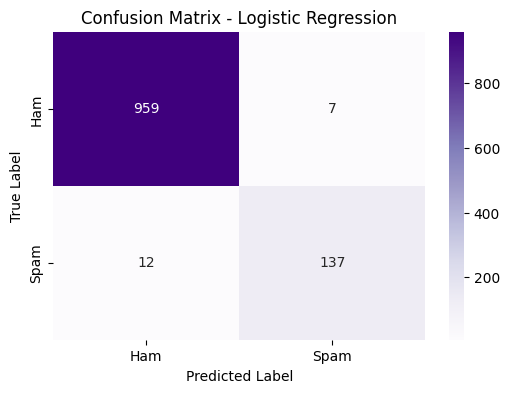

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.95      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## Naive Bayes

In [ ]:
naive_bayes = MultinomialNB(alpha=1.0)
naive_bayes.fit(X_train_resampled, y_train_resampled)

y_pred_nb = naive_bayes.predict(X_test_tfidf)
y_probs_nb = naive_bayes.predict_proba(X_test_tfidf)[:, 1]

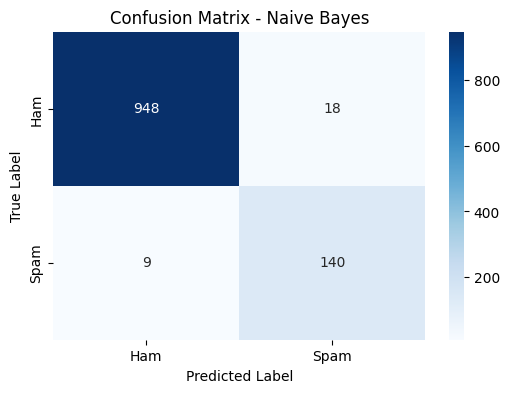

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       966
        spam       0.89      0.94      0.91       149

    accuracy                           0.98      1115
   macro avg       0.94      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## Linear SVM

In [ ]:
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_svm = svm_model.predict(X_test_tfidf)
y_probs_svm = svm_model.predict_proba(X_test_tfidf)[:, 1]

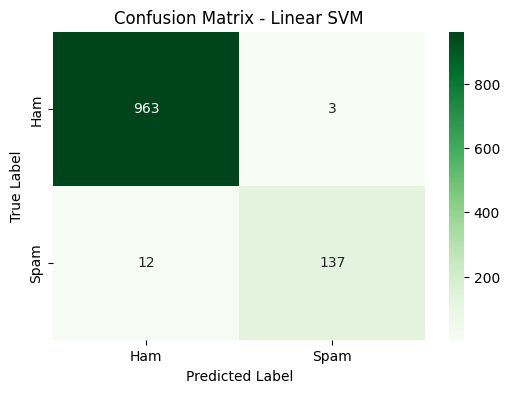

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Linear SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.98      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



## Ensemble (Voting) Classifier

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[('lr', log_reg), ('nb', naive_bayes), ('svm', svm_model)],
    voting='soft'
)
voting_clf.fit(X_train_resampled, y_train_resampled)

y_pred_voting = voting_clf.predict(X_test_tfidf)
y_probs_voting = voting_clf.predict_proba(X_test_tfidf)[:, 1]

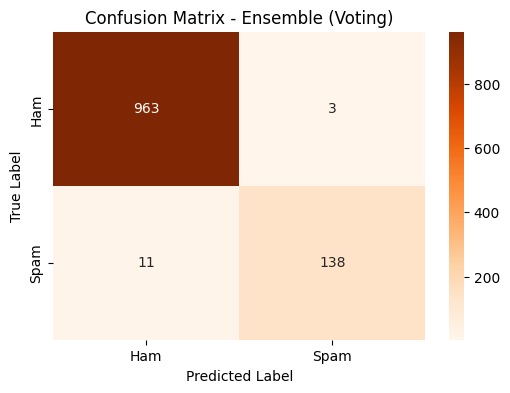

In [ ]:
cm_voting = confusion_matrix(y_test, y_pred_voting)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Oranges', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Ensemble (Voting)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_voting))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.98      0.93      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
p_label = 'spam' if 'spam' in y_test.values else 1
y_test_numeric = y_test.map({'ham': 0, 'spam': 1}) if isinstance(p_label, str) else y_test

all_preds = {
    'Logistic Regression': (y_pred_lr, y_probs_lr),
    'Naive Bayes': (y_pred_nb, y_probs_nb),
    'Linear SVM': (y_pred_svm, y_probs_svm),
    'Ensemble (Voting)': (y_pred_voting, y_probs_voting)
}

model_performance = []

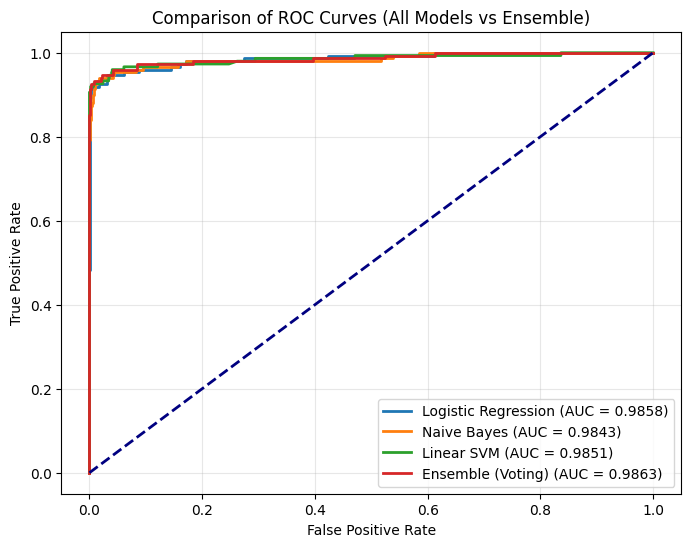

In [ ]:
plt.figure(figsize=(8, 6))
for name, (pred, probs) in all_preds.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, pos_label=p_label)
    rec = recall_score(y_test, pred, pos_label=p_label)
    f1 = f1_score(y_test, pred, pos_label=p_label)

    model_performance.append({
        'Model Name': name,
        'Accuracy': f"{acc:.2%}",
        'Precision': f"{prec:.2%}",
        'Recall': f"{rec:.2%}",
        'F1-Score': f"{f1:.2%}"
    })
    fpr, tpr, _ = roc_curve(y_test_numeric, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves (All Models vs Ensemble)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
df_performance = pd.DataFrame(model_performance)
df_performance

,Model Name,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,98.30%,95.14%,91.95%,93.52%
1,Naive Bayes,97.58%,88.61%,93.96%,91.21%
2,Linear SVM,98.65%,97.86%,91.95%,94.81%
3,Ensemble (Voting),98.74%,97.87%,92.62%,95.17%


# Download Model

In [ ]:
import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(voting_clf, 'ensemble_voting_model.pkl')

['ensemble_voting_model.pkl']